<a href="https://colab.research.google.com/github/Mohamedashraf2005/amazon_reviews_sentiment/blob/main/notebook/amazon_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import nltk
import re
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import numpy as np
import matplotlib.pyplot as plt
import re, string
from google.colab import drive
from wordcloud import WordCloud

In [ ]:
nltk.download('punkt')  # For word_tokenize
nltk.download('stopwords')  # For stopwords
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


path = '/content/drive/MyDrive/dataset/Reviews.csv'
df = pd.read_csv(path)

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


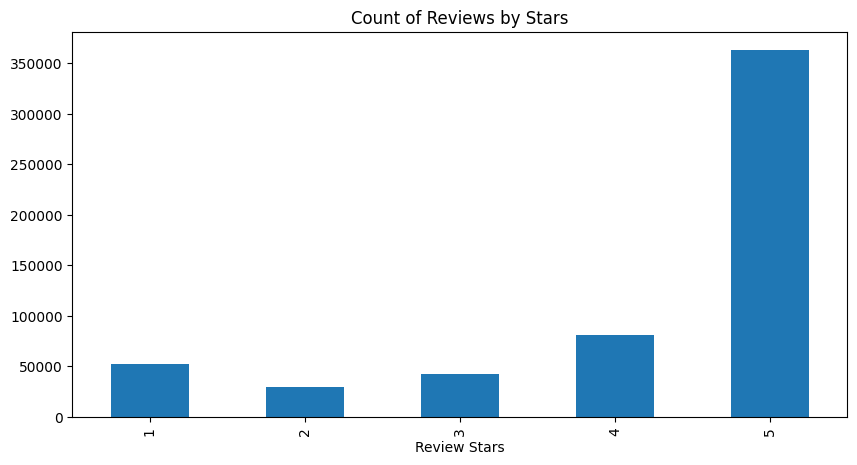

In [ ]:

ax = df['Score'].value_counts().sort_index() \
    .plot(kind='bar',
          title='Count of Reviews by Stars',
          figsize=(10, 5))
ax.set_xlabel('Review Stars')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [ ]:
df = df[['Text','Summary','Score']]

In [ ]:
df.head()

,Text,Summary,Score
0,I have bought several of the Vitality canned d...,Good Quality Dog Food,5
1,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised,1
2,This is a confection that has been around a fe...,"""Delight"" says it all",4
3,If you are looking for the secret ingredient i...,Cough Medicine,2
4,Great taffy at a great price. There was a wid...,Great taffy,5


#Data Cleaning

### Handle nulls

In [ ]:
df.isnull().sum()

,0
Text,0
Summary,27
Score,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
Text,0
Summary,0
Score,0


In [ ]:
df.shape

(568427, 3)

### Handle duplicates

In [ ]:
df.duplicated().sum()

np.int64(173424)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(395003, 3)

#Normalize text


### lowercasing

In [ ]:
def cleaning(text):



    text = re.sub(r'https?:\/\/\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'@[A-Za-z0-9_]+', ' ', text)
    text = re.sub(r'#[A-Za-z0-9_]+', ' ', text)
    text=re.sub(r'<.*?>',' ',text)
    text=text.lower()
    text = text.split()
    text = ' '.join(text)
    return text



In [ ]:
df['cleaning']=df['Text'].apply(cleaning)

### punctuation removal

In [ ]:
import string
punc=string.punctuation
def remove_punc(text):
    return text.translate(str.maketrans('','',punc))


In [ ]:
df['Remove_punc']=df['cleaning'].apply(remove_punc)

In [ ]:
df.head()

,Text,Summary,Score,cleaning,Remove_punc
0,I have bought several of the Vitality canned d...,Good Quality Dog Food,5,i have bought several of the vitality canned d...,i have bought several of the vitality canned d...
1,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised,1,product arrived labeled as jumbo salted peanut...,product arrived labeled as jumbo salted peanut...
2,This is a confection that has been around a fe...,"""Delight"" says it all",4,this is a confection that has been around a fe...,this is a confection that has been around a fe...
3,If you are looking for the secret ingredient i...,Cough Medicine,2,if you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...
4,Great taffy at a great price. There was a wid...,Great taffy,5,great taffy at a great price. there was a wide...,great taffy at a great price there was a wide ...


### Data Cleaning and Preparation

Before applying any modeling techniques, several data cleaning steps were performed to ensure data quality and consistency:

- **Handling Missing Values:**  
  Rows with null or missing values were removed to avoid introducing noise or bias into the model.

- **Removing Duplicates:**  
  Duplicate records were identified and removed to prevent data leakage and ensure that the model does not learn repeated patterns.

- **Text Normalization:**  
  The text data was normalized by:
  - Converting all text to lowercase  
  - Removing punctuation and special characters  
  - Eliminating unnecessary whitespace  

- **Irrelevant Data Removal:**  
  Any non-informative or irrelevant content (such as symbols, extra characters, or noisy text) was cleaned to improve the overall quality of the dataset.

- **Final Cleaning Adjustments:**  
  Additional preprocessing steps were applied as needed to ensure the text is in a consistent and model-ready format.

These steps helped in creating a clean and structured dataset, leading to more reliable and accurate model performance.

# Preprocessing

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

### word tokenization

In [ ]:
### word tokenization
from nltk.tokenize import word_tokenize
df['tokenized']=df['cleaning'].apply(word_tokenize)

In [ ]:
df.head()

,Text,Summary,Score,cleaning,Remove_punc,tokenized
0,I have bought several of the Vitality canned d...,Good Quality Dog Food,5,i have bought several of the vitality canned d...,i have bought several of the vitality canned d...,"[i, have, bought, several, of, the, vitality, ..."
1,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised,1,product arrived labeled as jumbo salted peanut...,product arrived labeled as jumbo salted peanut...,"[product, arrived, labeled, as, jumbo, salted,..."
2,This is a confection that has been around a fe...,"""Delight"" says it all",4,this is a confection that has been around a fe...,this is a confection that has been around a fe...,"[this, is, a, confection, that, has, been, aro..."
3,If you are looking for the secret ingredient i...,Cough Medicine,2,if you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...,"[if, you, are, looking, for, the, secret, ingr..."
4,Great taffy at a great price. There was a wid...,Great taffy,5,great taffy at a great price. there was a wide...,great taffy at a great price there was a wide ...,"[great, taffy, at, a, great, price, ., there, ..."


### Stopword removal

In [ ]:
def remove_stopWords(text):
    stop_word=set(stopwords.words('english'))
    filter_text=[word for word in text if word not in stop_word]
    return filter_text

In [ ]:
df['Nostopword_text']=df['tokenized'].apply(remove_stopWords)

In [ ]:
df.head()

,Text,Summary,Score,cleaning,Remove_punc,tokenized,Nostopword_text
0,I have bought several of the Vitality canned d...,Good Quality Dog Food,5,i have bought several of the vitality canned d...,i have bought several of the vitality canned d...,"[i, have, bought, several, of, the, vitality, ...","[bought, several, vitality, canned, dog, food,..."
1,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised,1,product arrived labeled as jumbo salted peanut...,product arrived labeled as jumbo salted peanut...,"[product, arrived, labeled, as, jumbo, salted,...","[product, arrived, labeled, jumbo, salted, pea..."
2,This is a confection that has been around a fe...,"""Delight"" says it all",4,this is a confection that has been around a fe...,this is a confection that has been around a fe...,"[this, is, a, confection, that, has, been, aro...","[confection, around, centuries, ., light, ,, p..."
3,If you are looking for the secret ingredient i...,Cough Medicine,2,if you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...,"[if, you, are, looking, for, the, secret, ingr...","[looking, secret, ingredient, robitussin, beli..."
4,Great taffy at a great price. There was a wid...,Great taffy,5,great taffy at a great price. there was a wide...,great taffy at a great price there was a wide ...,"[great, taffy, at, a, great, price, ., there, ...","[great, taffy, great, price, ., wide, assortme..."


### Lemmatization

In [ ]:
from nltk.stem import WordNetLemmatizer
lemmatizer=WordNetLemmatizer()
def lemmatizer_word(text):
 lemmas=[lemmatizer.lemmatize(word,pos='v') for word in text  ]
 return lemmas
df['lemmatizer_text']=df['Nostopword_text'].apply(lemmatizer_word)


In [ ]:
df.head()

,Text,Summary,Score,cleaning,Remove_punc,tokenized,Nostopword_text,lemmatizer_text
0,I have bought several of the Vitality canned d...,Good Quality Dog Food,5,i have bought several of the vitality canned d...,i have bought several of the vitality canned d...,"[i, have, bought, several, of, the, vitality, ...","[bought, several, vitality, canned, dog, food,...","[buy, several, vitality, can, dog, food, produ..."
1,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised,1,product arrived labeled as jumbo salted peanut...,product arrived labeled as jumbo salted peanut...,"[product, arrived, labeled, as, jumbo, salted,...","[product, arrived, labeled, jumbo, salted, pea...","[product, arrive, label, jumbo, salt, peanuts,..."
2,This is a confection that has been around a fe...,"""Delight"" says it all",4,this is a confection that has been around a fe...,this is a confection that has been around a fe...,"[this, is, a, confection, that, has, been, aro...","[confection, around, centuries, ., light, ,, p...","[confection, around, centuries, ., light, ,, p..."
3,If you are looking for the secret ingredient i...,Cough Medicine,2,if you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...,"[if, you, are, looking, for, the, secret, ingr...","[looking, secret, ingredient, robitussin, beli...","[look, secret, ingredient, robitussin, believe..."
4,Great taffy at a great price. There was a wid...,Great taffy,5,great taffy at a great price. there was a wide...,great taffy at a great price there was a wide ...,"[great, taffy, at, a, great, price, ., there, ...","[great, taffy, great, price, ., wide, assortme...","[great, taffy, great, price, ., wide, assortme..."


In [ ]:
df['clean_text'] = df['lemmatizer_text'].apply(lambda tokens: " ".join(tokens))


In [ ]:
text = " ".join(df['clean_text'])

In [ ]:
text

Buffered data was truncated after reaching the output size limit.

In [ ]:
wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Overall Word Cloud")
plt.show()

In [ ]:
df.drop(['cleaning','Remove_punc','tokenized','Nostopword_text','lemmatizer_text'],axis=1,inplace=True)

In [ ]:
df.head()